In [22]:
from cresowlve.utils import read_json

model_en_results_path = "../experiments/outputs/gemini-3.1-pro-preview/chgk_en_benchmark_eval_reasoning_model_en_s0_gemini-3.1-pro-preview_20260312_204451.json"
model_ru_results_path = "../experiments/outputs/gemini-3.1-pro-preview/chgk_ru_benchmark_eval_reasoning_model_ru_en_s0_gemini-3.1-pro-preview_20260313_232947.json"
model_en_results = read_json(model_en_results_path)
model_ru_results = read_json(model_ru_results_path)

In [23]:
en1_ids = [r["id"] for r in model_en_results["data"] if r.get("gpt-4o_judge_match", False)]
en0_ids = [r["id"] for r in model_en_results["data"] if not r.get("gpt-4o_judge_match", False)]
ru1_ids = [r["id"] for r in model_ru_results["data"] if r.get("gpt-4o_judge_match", False)]
ru0_ids = [r["id"] for r in model_ru_results["data"] if not r.get("gpt-4o_judge_match", False)]

en1_ru1_ids = set(en1_ids) & set(ru1_ids)
en1_ru0_ids = set(en1_ids) & set(ru0_ids)
en0_ru1_ids = set(en0_ids) & set(ru1_ids)
en0_ru0_ids = set(en0_ids) & set(ru0_ids)

In [16]:
culture_lang_results = read_json("../experiments/data/task/chgk_benchmark_culture_lang.json")

In [ ]:
from collections import Counter
cult_counter = Counter()

for sample_id in en0_ru1_ids:
    item = next((item for item in culture_lang_results["data"] if item["id"] == sample_id), None)
    if item:
        for cl in item.get("culture_langs", []):
            cult_counter[cl] += 1
        if len(item.get("culture_langs", [])) == 1:
            cult_counter[f"{item.get('culture_langs', [])[0]}_only"] += 1

cult_counter

Counter({'english': 158,
         'russian': 119,
         'english_only': 65,
         'russian_only': 44,
         'french': 33,
         'greek': 18,
         'german': 17,
         'italian': 14,
         'spanish': 9,
         'greek_only': 9,
         'japanese': 9,
         'polish': 9,
         'hebrew': 7,
         'latin': 7,
         'german_only': 5,
         'french_only': 5,
         'swedish': 5,
         'ukrainian': 4,
         'american': 4,
         'egyptian': 3,
         'biblical': 3,
         'norwegian': 3,
         'japanese_only': 3,
         'armenian': 2,
         'venezuelan': 2,
         'portuguese': 2,
         'lithuanian': 2,
         'romanian': 2,
         'hebrew_only': 2,
         'scottish': 2,
         'christianity': 2,
         'arabic': 2,
         'persian': 2,
         'dutch': 2,
         'indian': 2,
         'chinese': 2,
         'roman': 2,
         'turkish': 1,
         'european': 1,
         'european_only': 1,
         'argentinian

In [24]:
len(en0_ids), len(en1_ids), len(ru0_ids), len(ru1_ids)

(557, 1856, 337, 2076)

In [25]:
from cresowlve.utils import write_json

output_data = {
    "metadata": {
        "source": "../experiments/outputs/gemini-3.1-pro-preview/chgk_en_benchmark_eval_reasoning_model_en_s0_gemini-3.1-pro-preview_20260312_204451.json",
        "size": len(en0_ids)
    },
    "data": [{"id": sample_id} for sample_id in en0_ids]
}

write_json(output_data, "../experiments/data/error_analysis/gemini_3.1_pro_preview_en0_error_samples.json")

In [5]:
import random

error_samples = random.sample(en0_ids, 150)

In [7]:
from cresowlve.utils import write_json
import os

os.makedirs("../experiments/data/error_analysis/samples", exist_ok=True)

en0_sample1_outputs = {
    "metadata": {
        "sources": [model_en_results_path],
        "size": len(error_samples[:50]),
        "description": "Samples where model on English were wrong",
    },
    "data": list(error_samples[:50])
}
write_json(en0_sample1_outputs, "../experiments/data/error_analysis/samples/gemini_3_flash_preview_en0_sample1_ids.json")

en0_sample2_outputs = {
    "metadata": {
        "sources": [model_en_results_path],
        "size": len(error_samples[50:100]),
        "description": "Samples where model on English were wrong",
    },
    "data": list(error_samples[50:100])
}
write_json(en0_sample2_outputs, "../experiments/data/error_analysis/samples/gemini_3_flash_preview_en0_sample2_ids.json")

en0_sample3_outputs = {
    "metadata": {
        "sources": [model_en_results_path],
        "size": len(error_samples[100:150]),
        "description": "Samples where model on English were wrong",
    },
    "data": list(error_samples[100:150])
}
write_json(en0_sample3_outputs, "../experiments/data/error_analysis/samples/gemini_3_flash_preview_en0_sample3_ids.json")

In [7]:
len(en1_ru1_ids), len(en1_ru0_ids), len(en0_ru1_ids), len(en0_ru0_ids)

(1774, 82, 302, 255)

In [ ]:
from cresowlve.utils import write_json
import os

os.makedirs("../experiments/data/error_analysis", exist_ok=True)

# en1_ru1_outputs = {
#     "metadata": {
#         "sources": [model_en_results_path, model_ru_results_path],
#         "description": "Samples where model on both languages were correct",
#     },
#     "data": list(en1_ru1_ids)
# }
# write_json(en1_ru1_outputs, "../experiments/data/error_analysis/ru_vs_en/gemini_3_flash_preview_en1_ru1_ids.json")

# en1_ru0_outputs = {
#     "metadata": {
#         "sources": [model_en_results_path, model_ru_results_path],
#         "description": "Samples where model was correct on English but incorrect on Russian",
#     },
#     "data": list(en1_ru0_ids)
# }
# write_json(en1_ru0_outputs, "../experiments/data/error_analysis/ru_vs_en/gemini_3_flash_preview_en1_ru0_ids.json")

en0_ru1_outputs = {
    "metadata": {
        "sources": [model_en_results_path, model_ru_results_path],
        "description": "Samples where model was incorrect on English but correct on Russian",
    },
    "data": list(en0_ru1_ids)
}
write_json(en0_ru1_outputs, "../experiments/data/error_analysis/ru_vs_en/gemini_3_flash_preview_en0_ru1_ids.json")

# en0_ru0_outputs = {
#     "metadata": {
#         "sources": [model_en_results_path, model_ru_results_path],
#         "description": "Samples where model on both languages were incorrect",
#     },
#     "data": list(en0_ru0_ids)
# }
# write_json(en0_ru0_outputs, "../experiments/data/error_analysis/ru_vs_en/gemini_3_flash_preview_en0_ru0_ids.json")

In [12]:
from cresowlve.utils import write_json
import os

os.makedirs("../experiments/data/error_analysis", exist_ok=True)

en0_ru1_outputs = {
    "metadata": {
        "sources": [model_en_results_path, model_ru_results_path],
        "description": "Samples where model was incorrect on English but correct on Russian",
    },
    "data": list(en0_ru1_ids)
}
write_json(en0_ru1_outputs, "../experiments/data/error_analysis/ru_vs_en/gemini_3.1_pro_preview_en0_ru1_ids.json")

In [4]:
from cresowlve.utils import read_json, write_json

error_sample_files = ["../experiments/data/error_analysis/samples/gemini_3_flash_preview_en0_sample1_analysis.json", 
                    #   "../experiments/data/error_analysis/samples/gemini_3_flash_preview_en0_sample2_analysis.json",
                    #   "../experiments/data/error_analysis/samples/gemini_3_flash_preview_en0_sample3_analysis.json"
                    ]
error_categories = read_json("../experiments/data/error_analysis/error_categories.json")

In [5]:
for error_sample_file in error_sample_files:
    data = read_json(error_sample_file)
    for sample in data["data"]:
        analysis = sample.get("analysis", "")
        for error_cat, analysis_texts in error_categories["data"].items():
            if analysis.strip().lower() in [at.strip().lower() for at in analysis_texts]:
                sample["error_category"] = error_cat
                break
            if "error_category" in sample:
                break
    write_json(data, error_sample_file)

In [3]:
for error_sample_file in error_sample_files:
    data = read_json(error_sample_file)
    for sample in data["data"]:
        if "error_category" not in sample and sample.get("analysis", "") != "":
            print(sample["analysis"])

The model hallucinated a nonexistent character and book scene. Pure fabrication instead of lateral thinking.
Fabricated a scene with Magrat's wand catching fire. Didn't think about what connects two people through fire at a distance. False memory retrieval.
Wrong question
Overthought it. Went through reflections, subjects, the letter Я — never landed on the simple answer 'mirrors'.
The output text concludes with Cybele but the answer tag says snake. Contradicts itself.
Completely missed the Nekrasov reference. The hint says 'referring to the classics' and it invented a silver/gold proverb connection instead. Not creative, just wrong recall.
Missed the double meaning of 'размер'. 'The model fabricated a different Dzhigurda quote entirely.
Overthinking example. Correctly identified the book but got confused about who's talking to whom.
Built an elaborate butterfly theory with Nabokov. Totally wrong direction.
Fabricated a Gospel of Loki scene. The model hallucinated instead of reading th

In [11]:
from cresowlve.utils import read_json, write_json

invalid_samples = read_json("../experiments/data/error_analysis/invalid_samples.json")
target_datapath = "../experiments/data/eval/chgk_ru_benchmark_eval_reasoning_model_ru_en_s0.json"
target_data = read_json(target_datapath)
new_data = []

for sample in target_data["data"]:
    if sample["id"] not in invalid_samples["data"]:
        new_data.append(sample)

target_data["data"] = new_data
if "size" in target_data["metadata"]:
    target_data["metadata"]["size"] = len(new_data)
write_json(target_data, target_datapath)

In [1]:
from cresowlve.utils import read_json
from collections import Counter

gemini_traces = read_json("../experiments/data/error_analysis/gemini_3_flash_traces.json")

num_steps_dist = Counter([len(trace.get("conversation_history", [])) for trace in gemini_traces["data"]])

In [2]:
num_steps_dist

Counter({0: 9, 1: 6, 4: 5, 2: 4, 3: 3, 7: 1, 6: 1})

In [4]:
from cresowlve.utils import read_json

error_annot_results = read_json("../experiments/data/task/chgk_benchmark_error_annot_gemini_3.1_pro_en0.json")
en0_ru1_ids = read_json("../experiments/data/error_analysis/ru_vs_en/gemini_3.1_pro_preview_en0_ru1_ids.json")["data"]

In [5]:
error_cat_dist = []

for sample in error_annot_results["data"]:
    if sample["id"] in en0_ru1_ids:
        error_cat_dist.append(sample["error_category"])

In [3]:
from collections import Counter
Counter(error_cat_dist)

Counter({'Clue misinterpretation': 182,
         'Missing creative connection': 164,
         'Incorrect concept anchoring': 92,
         'Overthinking': 46,
         'Wrong reference': 37,
         'Wrong hypothesis': 30,
         'Hallucination': 3,
         'No error': 2,
         'Correct': 1})

In [4]:
from collections import Counter
Counter(error_cat_dist)

Counter({'Clue misinterpretation': 352,
         'Wrong reference': 350,
         'Missing creative connection': 194,
         'Incorrect concept anchoring': 74,
         'Wrong hypothesis': 52,
         'Overthinking': 48,
         'Hallucination': 16,
         'No error': 1})

In [1]:
from cresowlve.utils import read_json

model_results = read_json("../experiments/outputs/gemini-3.1-pro-preview/chgk_ru_benchmark_eval_reasoning_model_ru_en_s0_gemini-3.1-pro-preview_20260310_160621.json")

In [3]:
exact_match = {False: 0, True: 0}

for sample in model_results["data"]:
    if (sample["output"] and "chgk" in sample["output"].lower() or sample["thoughts"] and "chgk" in sample["thoughts"].lower()):
        if sample.get("gpt-4o_judge_match", False):
            exact_match[True] += 1
        else:
            exact_match[False] += 1

exact_match

{False: 45, True: 89}

In [7]:
from cresowlve.utils import read_json
from collections import Counter

error_annot_result_models = [
    ("GPT-4.1", "../experiments/data/task/chgk_benchmark_error_annot_gpt_4.1_en0.json"),
    ("GPT-5.4 (medium)", "../experiments/data/task/chgk_benchmark_error_annot_gpt_5.4_en0.json"),
    ("DeepSeek-V3.2 (adaptive)", "../experiments/data/task/chgk_benchmark_error_annot_deepseek_v3.2_en0.json"),
    ("Gemini-3-Flash (medium)", "../experiments/data/task/chgk_benchmark_error_annot_gemini_3_flash_en0.json"),
    ("Gemini-3.1-Pro (high)", "../experiments/data/task/chgk_benchmark_error_annot_gemini_3.1_pro_en0.json")
]

error_annot_results_data = []
error_categories = [
    "Missing creative connection",
    "Clue misinterpretation",
    "Incorrect concept anchoring",
    "Wrong reference",
    "Overthinking",
    "Wrong hypothesis",
    "Hallucination"
]

for model_name, file_path in error_annot_result_models:
    results = read_json(file_path)
    error_annot_counter = Counter([sample["error_category"] for sample in results["data"] if "error_category" in sample])
    total_samples = sum(error_annot_counter.values())
    error_annot_results_data.append({
        "model": model_name,
        **{error_cat: error_annot_counter.get(error_cat, 0)/total_samples for error_cat in error_annot_counter if error_cat in error_categories},
        "total_samples": total_samples
    })

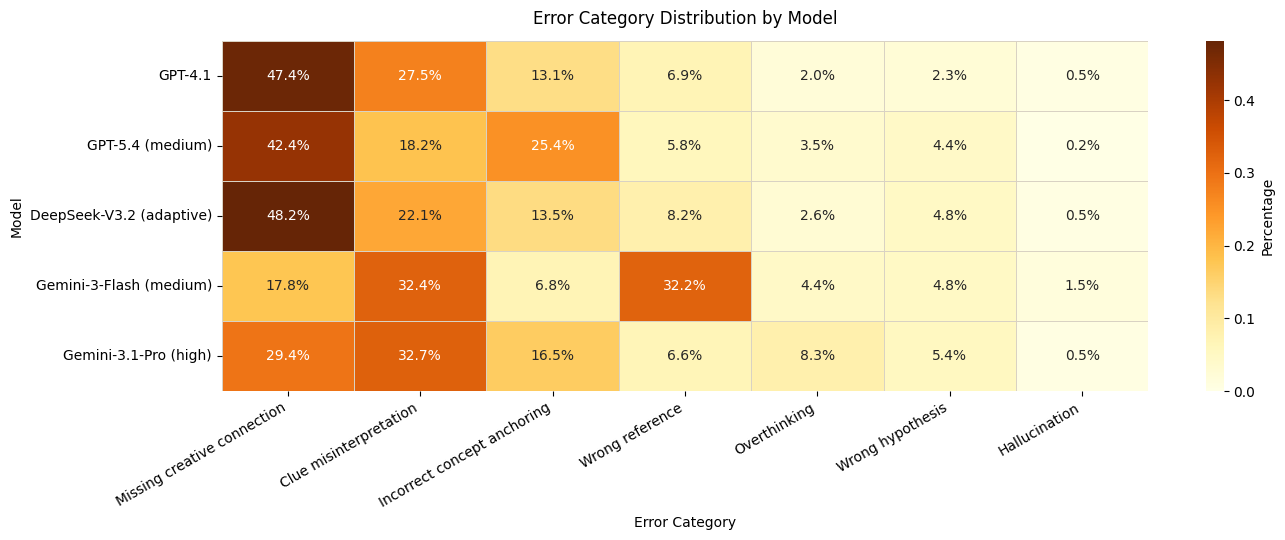

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Build a matrix in a fixed category order so every model is comparable.
heatmap_df = pd.DataFrame(error_annot_results_data)
heatmap_df = heatmap_df.set_index("model")
heatmap_df = heatmap_df.reindex(columns=error_categories, fill_value=0.0)

plt.figure(figsize=(14, 5.5))
ax = sns.heatmap(
    heatmap_df,
    cmap=sns.color_palette("YlOrBr", as_cmap=True),  # earthy yellow-orange-brown
    annot=True,
    fmt=".1%",
    linewidths=0.5,
    linecolor="#d9d2c3",
    cbar_kws={"label": "Percentage"},
    vmin=0,
    vmax=max(heatmap_df.to_numpy().max(), 0.01),
)

ax.set_title("Error Category Distribution by Model", pad=12)
ax.set_xlabel("Error Category")
ax.set_ylabel("Model")
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("../figures/error-category-dist.pdf", dpi=360, bbox_inches="tight", facecolor="white")